In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import os
from torchsummary import summary
import csv
# ====================
# Config
# ====================
latent_dim = 100
img_size = 28
channels = 1
batch_size = 64
epochs = 50
n_critic = 5         # Critic steps per generator step
clip_value = 0.01    # Weight clipping
lr = 0.00005         # Learning rate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("images_wgan", exist_ok=True)

# ====================
# Data Loader
# ====================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Scale to [-1, 1]
])

dataloader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# ====================
# Models
# ====================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), 1, img_size, img_size)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(img_size * img_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)  # No sigmoid
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

# ====================
# Initialize models
# ====================
generator = Generator().to(device)
critic = Critic().to(device)




In [7]:
# --- Print Generator Summary ---
# Input shape is the 1D noise vector
print("------------------------------------------------------------")
print("                   WGAN Generator Summary")
print("------------------------------------------------------------")
summary(generator, (latent_dim,))

------------------------------------------------------------
                   WGAN Generator Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 784]                 --
|    └─Linear: 2-1                       [-1, 128]                 12,928
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 256]                 33,024
|    └─BatchNorm1d: 2-4                  [-1, 256]                 512
|    └─ReLU: 2-5                         [-1, 256]                 --
|    └─Linear: 2-6                       [-1, 512]                 131,584
|    └─BatchNorm1d: 2-7                  [-1, 512]                 1,024
|    └─ReLU: 2-8                         [-1, 512]                 --
|    └─Linear: 2-9                       [-1, 784]                 402,192
|    └─Tanh: 2-10                      

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 784]                 --
|    └─Linear: 2-1                       [-1, 128]                 12,928
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 256]                 33,024
|    └─BatchNorm1d: 2-4                  [-1, 256]                 512
|    └─ReLU: 2-5                         [-1, 256]                 --
|    └─Linear: 2-6                       [-1, 512]                 131,584
|    └─BatchNorm1d: 2-7                  [-1, 512]                 1,024
|    └─ReLU: 2-8                         [-1, 512]                 --
|    └─Linear: 2-9                       [-1, 784]                 402,192
|    └─Tanh: 2-10                        [-1, 784]                 --
Total params: 581,264
Trainable params: 581,264
Non-trainable params: 0
Total mult-adds (M): 1.16
Input size (MB): 0.00
Forward/backw

In [8]:
# --- Print Discriminator Summary ---
# Input shape is the 2D image
print("\n\n------------------------------------------------------------")
print("                WGAN Critic Summary")
print("------------------------------------------------------------")
summary(critic, (channels, img_size, img_size))



------------------------------------------------------------
                WGAN Critic Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1]                   --
|    └─Linear: 2-1                       [-1, 512]                 401,920
|    └─LeakyReLU: 2-2                    [-1, 512]                 --
|    └─Linear: 2-3                       [-1, 256]                 131,328
|    └─LeakyReLU: 2-4                    [-1, 256]                 --
|    └─Linear: 2-5                       [-1, 1]                   257
Total params: 533,505
Trainable params: 533,505
Non-trainable params: 0
Total mult-adds (M): 1.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.04
Estimated Total Size (MB): 2.04


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1]                   --
|    └─Linear: 2-1                       [-1, 512]                 401,920
|    └─LeakyReLU: 2-2                    [-1, 512]                 --
|    └─Linear: 2-3                       [-1, 256]                 131,328
|    └─LeakyReLU: 2-4                    [-1, 256]                 --
|    └─Linear: 2-5                       [-1, 1]                   257
Total params: 533,505
Trainable params: 533,505
Non-trainable params: 0
Total mult-adds (M): 1.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.04
Estimated Total Size (MB): 2.04

In [ ]:
optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
optimizer_C = optim.RMSprop(critic.parameters(), lr=lr)

# Loss trackers
gen_losses = []
critic_losses = []

loss_file_path = "simple_wgan.csv"
# Prepare CSV file for logging
with open(loss_file_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "Critic_Loss", "Generator_Loss"])

# ====================
# Training
# ====================
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        real_imgs = imgs.to(device)

        # ---------------------
        # Train Critic
        # ---------------------
        optimizer_C.zero_grad()

        z = torch.randn(imgs.size(0), latent_dim, device=device)
        fake_imgs = generator(z)

        loss_C = -torch.mean(critic(real_imgs)) + torch.mean(critic(fake_imgs.detach()))
        loss_C.backward()
        optimizer_C.step()

        # Weight clipping for Lipschitz constraint
        for p in critic.parameters():
            p.data.clamp_(-clip_value, clip_value)

        # ---------------------
        # Train Generator every n_critic steps
        # ---------------------
        if i % n_critic == 0:
            optimizer_G.zero_grad()

            z = torch.randn(imgs.size(0), latent_dim, device=device)
            gen_imgs = generator(z)
            loss_G = -torch.mean(critic(gen_imgs))
            loss_G.backward()
            optimizer_G.step()

    # Save epoch losses
    gen_losses.append(loss_G.item())
    critic_losses.append(loss_C.item())
    with open(loss_file_path, 'a', newline='') as f:
        csv.writer(f).writerow([epoch + 1, loss_C.item(), loss_G.item()])
    print(f"[Epoch {epoch+1}/{epochs}] C loss: {loss_C.item():.4f} | G loss: {loss_G.item():.4f}")

    # Save generated images
    save_image(gen_imgs.data[:25], f"images_wgan/{epoch+1}.png", nrow=5, normalize=True)

print("Training Complete — WGAN results saved in 'images_wgan/' folder")

[Epoch 1/50] C loss: -0.1313 | G loss: -15.7220
[Epoch 2/50] C loss: -0.0584 | G loss: -12.4287
[Epoch 3/50] C loss: -0.0105 | G loss: -10.6477
[Epoch 4/50] C loss: -0.0364 | G loss: -10.1033
[Epoch 5/50] C loss: 0.0034 | G loss: -7.1150
[Epoch 6/50] C loss: 0.0119 | G loss: -6.3509
[Epoch 7/50] C loss: 0.0115 | G loss: -5.4474
[Epoch 8/50] C loss: -0.0149 | G loss: -4.6959
[Epoch 9/50] C loss: -0.0010 | G loss: -3.8881
[Epoch 10/50] C loss: -0.0544 | G loss: -4.0492
[Epoch 11/50] C loss: -0.0475 | G loss: -1.4646
[Epoch 12/50] C loss: -0.0730 | G loss: -2.2339
[Epoch 13/50] C loss: -0.0800 | G loss: -0.8706
[Epoch 14/50] C loss: -0.1199 | G loss: -0.4001
[Epoch 15/50] C loss: -0.1504 | G loss: 0.3694
[Epoch 16/50] C loss: -0.1012 | G loss: -0.5030
[Epoch 17/50] C loss: -0.1291 | G loss: -0.7673
[Epoch 18/50] C loss: -0.1487 | G loss: -0.9659
[Epoch 19/50] C loss: -0.1933 | G loss: -0.9489
[Epoch 20/50] C loss: -0.1703 | G loss: -0.3480
[Epoch 21/50] C loss: -0.1929 | G loss: -0.5543
[

: 

Attempting to plot from simple_wgan.csv...
Plot saved successfully to simple_wgan_plot.png


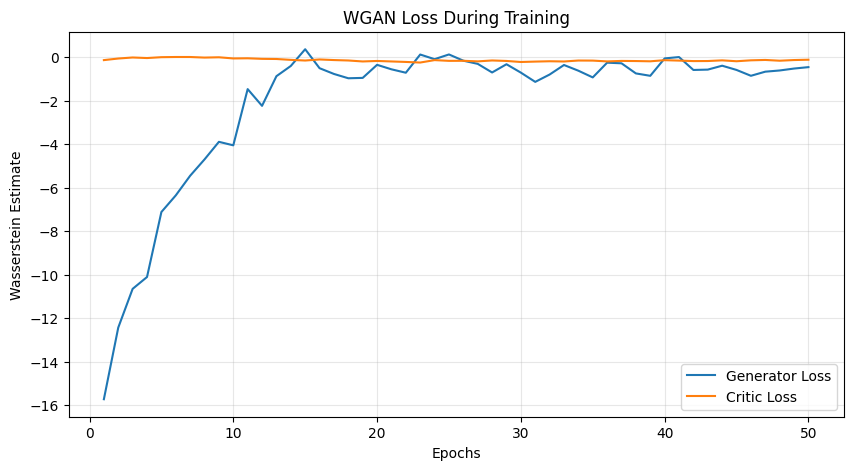

In [1]:

import matplotlib.pyplot as plt
import pandas as pd

# Define file paths
loss_file = "simple_wgan.csv"
output_plot = "simple_wgan_plot.png"

print(f"Attempting to plot from {loss_file}...")

try:
    # Read the data from the CSV file using pandas
    df = pd.read_csv(loss_file)

    # Create the plot
    plt.figure(figsize=(10, 5))
    plt.plot(df["Epoch"], df["Generator_Loss"], label="Generator Loss")
    plt.plot(df["Epoch"], df["Critic_Loss"], label="Critic Loss")
    
    plt.title("WGAN Loss During Training")
    plt.xlabel("Epochs")
    plt.ylabel("Wasserstein Estimate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save the plot to a file
    plt.savefig(output_plot)
    print(f"Plot saved successfully to {output_plot}")
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{loss_file}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

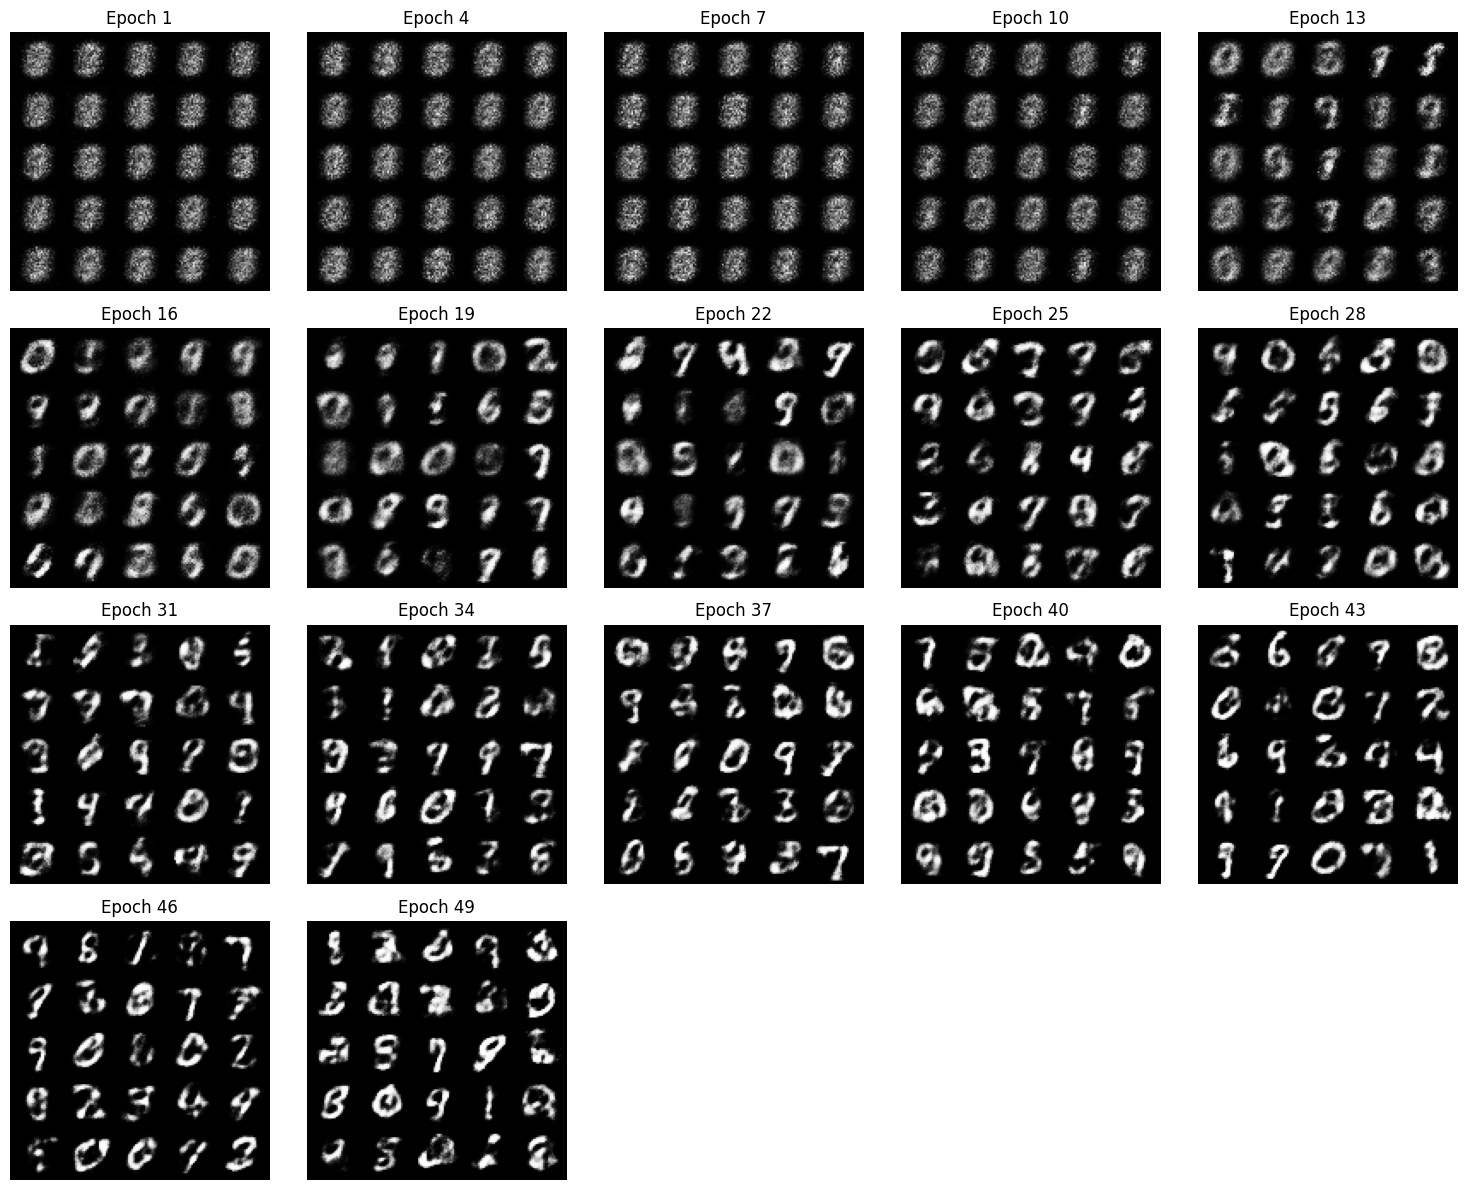

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = "images_wgan"
epochs = 50
step = 3

# Collect epochs to display
selected_epochs = list(range(1, epochs+1, step))

# Calculate grid size
cols = 5  # number of images per row
rows = (len(selected_epochs) + cols - 1) // cols

# Prepare the figure
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))

for idx, epoch in enumerate(selected_epochs):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]

    img_path = os.path.join(folder, f"{epoch}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
    ax.axis('off')

# Turn off any empty subplots
for i in range(len(selected_epochs), rows*cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis('off')

plt.tight_layout()
plt.savefig("wgan_progress_every5.png")
plt.show()
